# Business Insights and Recommendations

## Aim

The primary objective of this notebook is to translate the results of the customer churn prediction model into meaningful business insights and actionable recommendations.

Using the cleaned customer data and the final machine learning model, this notebook explores the key factors influencing customer churn, identifies high-risk customer segments, and highlights important behavioral patterns associated with churn. The findings are then used to propose data-driven retention strategies that can help the business improve customer satisfaction, reduce churn, and increase long-term customer value.

By combining exploratory analysis with model interpretation, this notebook demonstrates how machine learning can support business decision-making and enable proactive customer retention initiatives.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
df = pd.read_csv("customer.csv")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### Data Preparation

The original dataset contains several identifier, location-specific, and post-churn information columns that are not required for business insight generation. These columns are removed to simplify the analysis and focus on variables that influence customer churn.

In [3]:
columns_to_drop = [
    "City",
    "Zip Code",
    "CustomerID",
    "Count",
    "Churn Label",
    "Churn Score",
    "Churn Reason",
    "CLTV",
    "Lat Long"
]

df = df.drop(columns=columns_to_drop)

## Overall Churn Rate

In [4]:
churn_rate = (
    df["Churn Value"].value_counts(normalize=True) * 100
)

print(churn_rate)

0    73.463013
1    26.536987
Name: Churn Value, dtype: float64


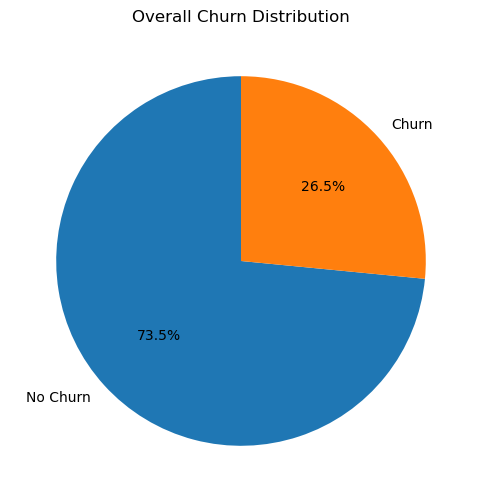

In [20]:
plt.figure(figsize=(6,6))

df["Churn Value"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["No Churn","Churn"],
    startangle=90
)

plt.ylabel("")

plt.title("Overall Churn Distribution")
plt.show()

## Churn by Contract Type

In [6]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Value"],
    normalize="index"
) * 100

contract_churn

Churn Value,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


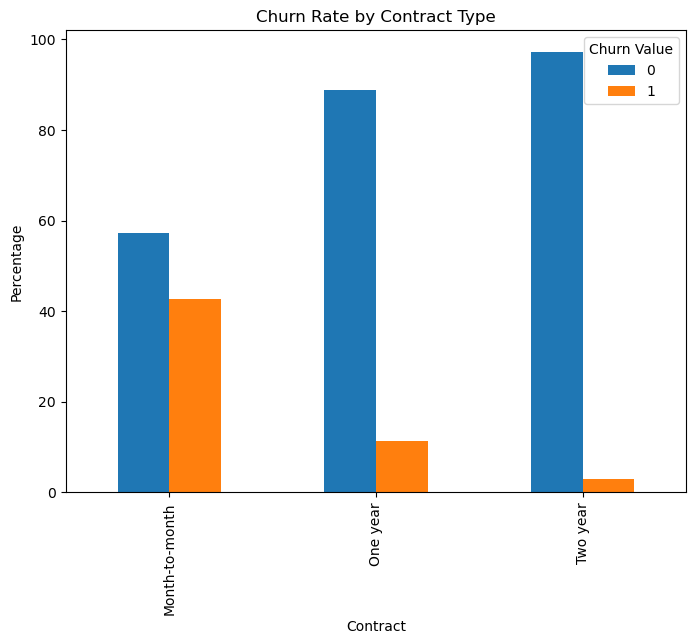

In [7]:
contract_churn.plot(
    kind="bar",
    figsize=(8,6)
)

plt.ylabel("Percentage")

plt.title("Churn Rate by Contract Type")

plt.show()

## Churn by Internet Service

In [8]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Value"],
    normalize="index"
) * 100

internet_churn

Churn Value,0,1
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


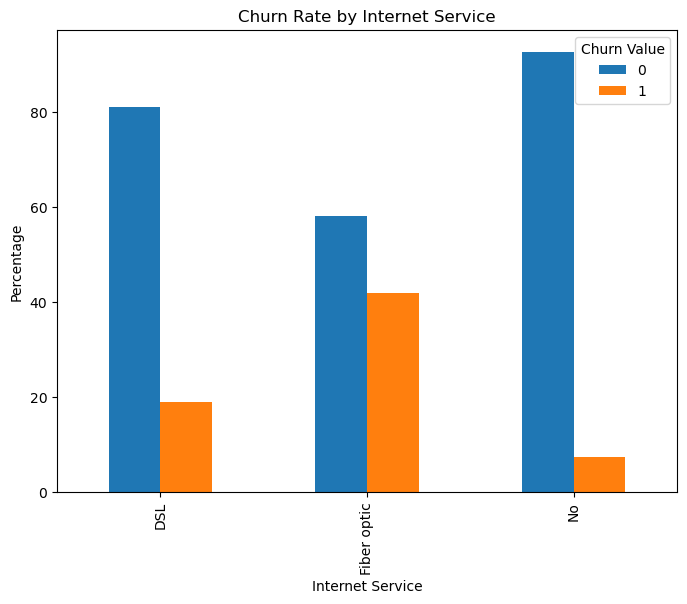

In [9]:
internet_churn.plot(
    kind="bar",
    figsize=(8,6)
)

plt.ylabel("Percentage")

plt.title("Churn Rate by Internet Service")

plt.show()

## Churn by Payment Method

In [10]:
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Value"],
    normalize="index"
) * 100

payment_churn

Churn Value,0,1
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


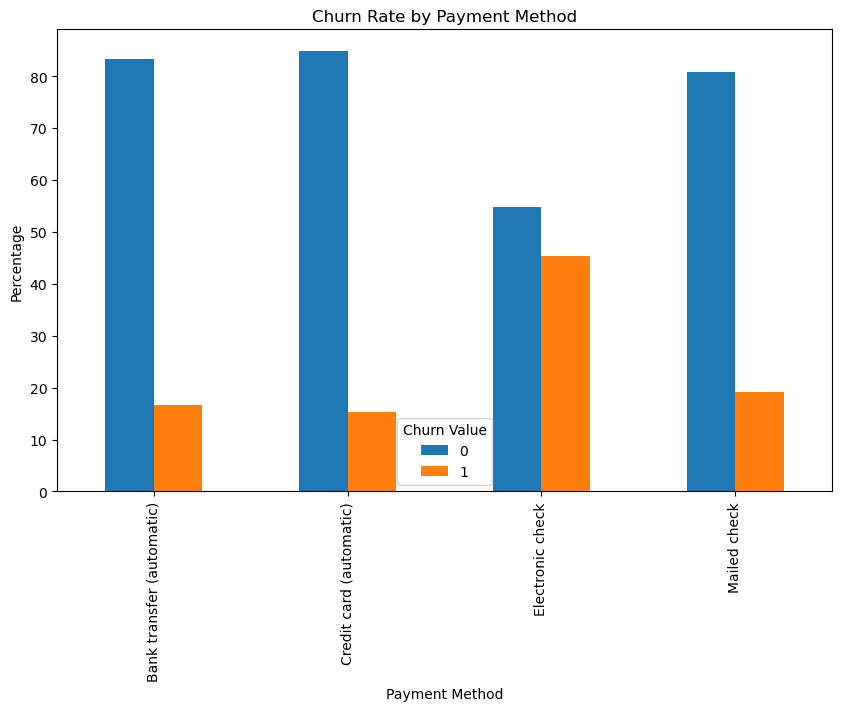

In [11]:
payment_churn.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Percentage")

plt.title("Churn Rate by Payment Method")

plt.show()

## Churn by Senior Citizen

In [12]:
senior_churn = pd.crosstab(
    df["Senior Citizen"],
    df["Churn Value"],
    normalize="index"
) * 100

senior_churn

Churn Value,0,1
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


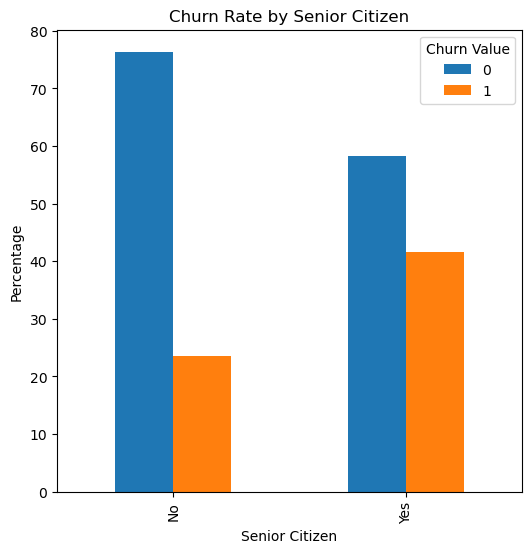

In [13]:
senior_churn.plot(
    kind="bar",
    figsize=(6,6)
)

plt.ylabel("Percentage")

plt.title("Churn Rate by Senior Citizen")

plt.show()

## Monthly Charges Distribution

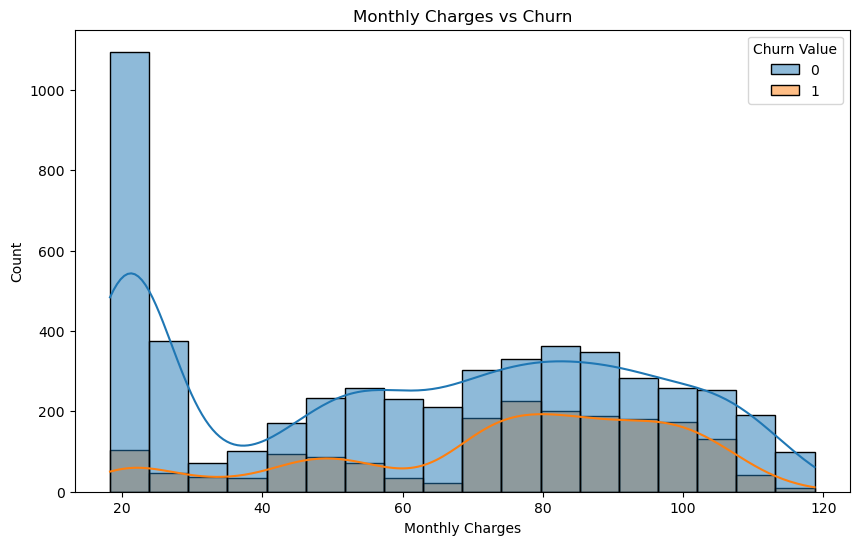

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Monthly Charges",
    hue="Churn Value",
    kde=True
)

plt.title("Monthly Charges vs Churn")

plt.show()

## Tenure Distribution

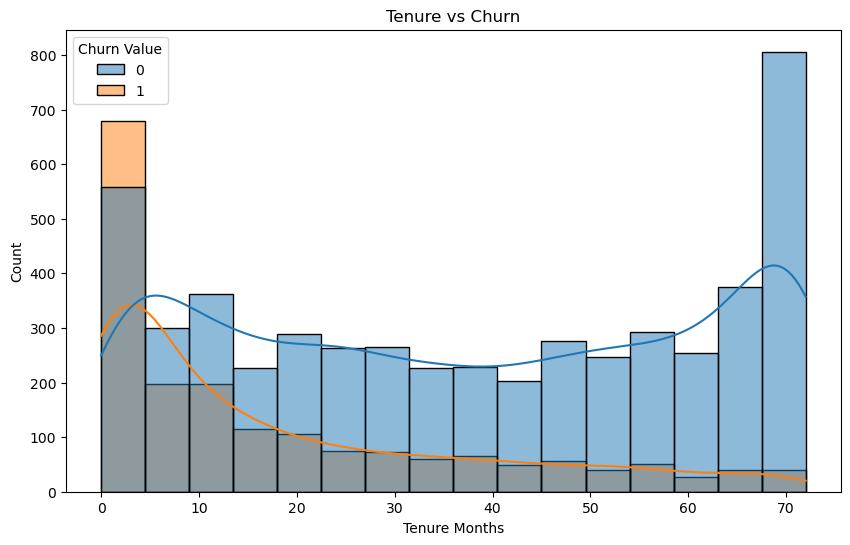

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Tenure Months",
    hue="Churn Value",
    kde=True
)

plt.title("Tenure vs Churn")

plt.show()

## Correlation Heatmap

<AxesSubplot:>

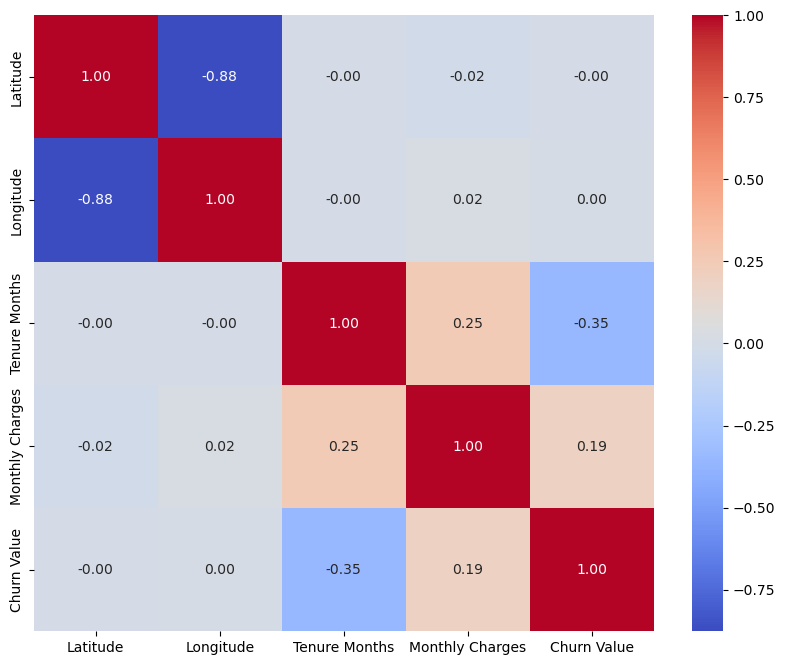

In [21]:
corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

## Business Recommendations

Based on the analysis, the following strategies are recommended:

- Encourage customers to switch from month-to-month contracts to long-term contracts.
- Design retention campaigns for new customers with short tenure.
- Offer personalized discounts to customers with high monthly charges.
- Promote automatic payment methods to improve customer retention.
- Prioritize proactive engagement with customer segments exhibiting higher churn rates.

## Executive Summary

Key findings from the business analysis include:

- Month-to-month contracts are strongly associated with customer churn.
- Customers with shorter tenure are significantly more likely to churn.
- Customers with higher monthly charges exhibit higher churn rates.
- Certain payment methods are associated with increased churn.
- These insights can support targeted retention strategies and improve long-term customer loyalty.